# W2246-0526: Method Comparison

Side-by-side comparison of three source-finding approaches applied to the same W2246 ALMA CII cube:

| Method | Algorithm | Diffuse handling |
|--------|-----------|------------------|
| **Ours** | Per-channel starlet wavelet + TV-L1 optical flow tracking | Compact scales only — diffuse filtered by construction |
| **SoFiA S+C** | Smooth + Clip at multiple scales (Serra et al. 2015) | None — detects all emission above threshold |
| **astrodendro** | 3-D hierarchical dendrogram on raw cube | Hierarchical — diffuse becomes trunk/branch |

**No ground truth available for W2246** — comparison is qualitative: which sources are found, footprint extents, and false positives.

## Imports

In [ ]:
%matplotlib inline
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.ndimage import (
    gaussian_filter, gaussian_filter1d,
    label as nd_label, binary_dilation,
)
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.cosmology import Planck18
import astropy.units as u

_scripts = Path('../scripts')
if str(_scripts) not in sys.path:
    sys.path.insert(0, str(_scripts))

from nemo.utils import add_beam

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

## Load W2246 Cube

In [ ]:
from nemo import active_channels

USE_DENOISED = True

_RAW_FITS      = '/Users/arnablahiry/repos/IFU-Source-ID/data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314.fits'
_DENOISED_FITS = '/Users/arnablahiry/repos/IFU-Source-ID/data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314_denoised_ist.fits'
_CUBE_PATH     = _DENOISED_FITS if USE_DENOISED else _RAW_FITS
_label         = 'IST-denoised' if USE_DENOISED else 'raw'

with afits.open(_CUBE_PATH) as _hdul:
    _hdr = _hdul[0].header.copy()
    cube = np.ascontiguousarray(np.squeeze(_hdul[0].data), dtype=np.float32)

np.nan_to_num(cube, copy=False, nan=0.0)
np.clip(cube, 0.0, None, out=cube)

n_ch, H, W = cube.shape
_RESULTS_DIR = f'../results/comparison_w2246_{n_ch}'
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# Velocity array from WCS
_C_KMS   = 299792.458
_crval3  = float(_hdr['CRVAL3'])
_cdelt3  = float(_hdr['CDELT3'])
_crpix3  = float(_hdr['CRPIX3'])
_restfrq = float(_hdr['RESTFRQ'])
_freq_arr = _crval3 + _cdelt3 * (np.arange(n_ch) - (_crpix3 - 1))
vel_array = (_C_KMS * (_restfrq - _freq_arr) / _restfrq).astype(np.float64)

# Pixel scale in kpc
_z           = 4.6
_pixscale_as = abs(float(_hdr['CDELT1'])) * 3600
_kpc_per_as  = Planck18.kpc_proper_per_arcmin(_z).to('kpc/arcsec').value
pixscale_kpc = _pixscale_as * _kpc_per_as

# Beam
BMAJ_DEG = float(_hdr.get('BMAJ', 0.0))
BMIN_DEG = float(_hdr.get('BMIN', BMAJ_DEG))
BPA_DEG  = float(_hdr.get('BPA',  0.0))
BMAJ_PIX = BMAJ_DEG * 3600 / (_pixscale_as)
BMIN_PIX = BMIN_DEG * 3600 / (_pixscale_as)

# Active channels
print(f'Cube ({_label})  : {cube.shape}')
print(f'Velocity range    : [{vel_array.min():.1f}, {vel_array.max():.1f}] km/s')
print(f'Pixel scale       : {pixscale_kpc:.3f} kpc/px')
print(f'Beam              : {BMAJ_PIX:.1f} × {BMIN_PIX:.1f} px')
print(f'Active channels   : {len(channel_list)}  (ch {channel_list[0]}–{channel_list[-1]})')
print(f'Detection floor   : {W2246_THRESH:.3e}')

## Method 1 — Wavelet + Optical Flow (Ours)

In [ ]:
detector = WaveletDetector(
    scales=6, k_sigma=5.0, use_scale=4, min_area=10,
    thresh=W2246_THRESH, use_mean_map_sigma=True,
)

tracker = FlowTracker(
    detector=detector,
    min_match_overlap=5, min_split_overlap=3,
    max_gap_dist=15.0, max_gap_channels=5,
    min_displacement=3.0,
    wav_abrupt_thresh=0.5, flow_iou_thresh=0.25,
)

result = tracker.run(
    cube,
    channel_list=channel_list,
    vel_array=vel_array,
    results_dir=_RESULTS_DIR,
    plot=False, verbose=True,
)

detections = result.detections
flow_seq   = result.flow_seq
tracks     = result.tracks
sources    = result.sources
src_data   = result.src_data
src_colors = result.src_colors

frames    = [(d.channel, d.image, d.footprint_masks, d.peaks, d.boxes)
             for d in detections]
flow_data = list(flow_seq)

mask_to_source: dict[int, int] = {}
for t in tracks:
    for ch, mask in t['masks'].items():
        mask_to_source[id(mask)] = t['source_id']

def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

our_footprints = {}
for src in sources:
    m = np.zeros((H, W), dtype=bool)
    for t in tracks:
        if t['id'] in src['track_ids']:
            for mask in t['masks'].values():
                m |= mask
    our_footprints[src['id']] = m

print(f'\nNEMO found {len(sources)} source(s).')

plt.rcParams.update(plt.rcParamsDefault)


## Method 2 — SoFiA Smooth + Clip (S+C)

Python reimplementation of the SoFiA-2 S+C finder (Serra et al. 2015, Westmeier et al. 2021).

**Algorithm:**
1. Smooth cube with each combination of spatial kernel σ_xy and spectral kernel σ_z
2. Estimate per-channel noise via MAD on each smoothed cube
3. Threshold at `k × σ` — keep voxels above threshold in any smoothing combination
4. Label 3-D connected components; apply minimum size filter
5. Each connected component = one source candidate

In [5]:
def sofia_sc(
    cube: np.ndarray,
    channel_list: list[int],
    spatial_kernels: list[float] = (0, 3, 6),
    spectral_kernels: list[float] = (0, 3, 7),
    k_sigma: float = 4.0,
    min_voxels: int = 20,
) -> tuple[np.ndarray, list[dict]]:
    """SoFiA-style smooth+clip on a subcube of channel_list.

    Returns
    -------
    detection_mask : bool (n_ch, H, W) — union across all smoothing scales
    sources        : list of dicts with 'mask3d', 'mom0', 'centroid_yx',
                     'ch_range', 'n_voxels'
    """
    sub = cube[channel_list].astype(np.float32)   # (n_active, H, W)
    n_active, H, W = sub.shape

    union_mask = np.zeros((n_active, H, W), dtype=bool)

    for s_xy in spatial_kernels:
        for s_z in spectral_kernels:
            # Smooth
            if s_xy > 0 and s_z > 0:
                sm = gaussian_filter(sub, sigma=(s_z, s_xy, s_xy))
            elif s_xy > 0:
                sm = gaussian_filter(sub, sigma=(0, s_xy, s_xy))
            elif s_z > 0:
                sm = gaussian_filter1d(sub, sigma=s_z, axis=0)
            else:
                sm = sub.copy()

            # Noise: MAD per channel (robust estimator)
            med  = np.median(sm, axis=(1, 2), keepdims=True)
            mad  = np.median(np.abs(sm - med), axis=(1, 2), keepdims=True)
            sigma = mad / 0.6745  # MAD → Gaussian sigma
            sigma = np.where(sigma < 1e-30, 1e-30, sigma)

            union_mask |= (sm >= k_sigma * sigma)

    # 3-D connected components
    struct = np.ones((3, 3, 3), dtype=bool)   # 26-connectivity
    labelled, n_labels = nd_label(union_mask, structure=struct)

    sources = []
    for lab in range(1, n_labels + 1):
        m3 = labelled == lab
        if m3.sum() < min_voxels:
            union_mask[m3] = False
            continue
        mom0 = m3.sum(axis=0).astype(bool)   # spatial footprint
        chs  = np.where(m3.any(axis=(1, 2)))[0]
        rows, cols = np.where(mom0)
        sources.append({
            'mask3d'     : m3,
            'footprint'  : mom0,
            'centroid_yx': (float(rows.mean()), float(cols.mean())),
            'ch_range'   : (int(channel_list[chs[0]]), int(channel_list[chs[-1]])),
            'n_voxels'   : int(m3.sum()),
        })

    return union_mask, sources


# ── Run S+C ───────────────────────────────────────────────────────────────
sofia_union_mask, sofia_sources = sofia_sc(
    cube,
    channel_list=channel_list,
    spatial_kernels=[0, 3, 6],
    spectral_kernels=[0, 3, 7],
    k_sigma=4.0,
    min_voxels=20,
)

# Sort by voxel count descending (largest = most significant)
sofia_sources.sort(key=lambda s: s['n_voxels'], reverse=True)

print(f'SoFiA S+C found {len(sofia_sources)} source(s)  '
      f'(union mask: {sofia_union_mask.sum()} voxels above threshold)')
for i, s in enumerate(sofia_sources):
    cy, cx = s['centroid_yx']
    ch0, ch1 = s['ch_range']
    v0, v1 = vel_array[ch0], vel_array[ch1]
    print(f'  S{i+1}: centroid=({cx:.0f}, {cy:.0f}) px  '
          f'ch {ch0}–{ch1}  [{v0:.0f}, {v1:.0f}] km/s  '
          f'{s["n_voxels"]} voxels')

SoFiA S+C found 3 source(s)  (union mask: 3625579 voxels above threshold)
  S1: centroid=(98, 105) px  ch 88–245  [-677, 893] km/s  3555481 voxels
  S2: centroid=(175, 23) px  ch 163–245  [73, 893] km/s  66199 voxels
  S3: centroid=(31, 165) px  ch 195–227  [393, 713] km/s  3899 voxels


## Method 3 — astrodendro (compact leaves only)

3-D hierarchical dendrogram on the cube subcube, tuned to return only compact sources.

Key parameters for compactness:
- **`min_delta`** — how much a leaf peak must exceed its parent branch. High value → only sharp, compact peaks survive as independent leaves; diffuse emission (shallow gradient) gets absorbed into the trunk.
- **`max_footprint_px`** — post-filter: reject any leaf whose 2-D spatial footprint exceeds this area. Removes residual extended leaves that slipped through.


In [8]:
import astrodendro

_sub_dendro = cube[channel_list].astype(np.float64)
_noise_mad  = np.median(np.abs(_sub_dendro - np.median(_sub_dendro))) / 0.6745

# Edge mask: ignore the outer N pixels of the spatial FOV where sensitivity drops
_EDGE = 10
_edge_mask = np.zeros((H, W), dtype=bool)
_edge_mask[_EDGE:H-_EDGE, _EDGE:W-_EDGE] = True

# ── Parameters ────────────────────────────────────────────────────────────
_min_value        = W2246_THRESH          # same floor as our method
_min_delta        = 3.0 * _noise_mad      # moderate — compact peaks stand above parent by 3σ
_min_npix         = 100                   # minimum voxels per structure
_max_footprint_px = 1200                  # max 2-D spatial footprint area (≈ r_eff < 20 px)

d = astrodendro.Dendrogram.compute(
    _sub_dendro,
    min_value = _min_value,
    min_delta = _min_delta,
    min_npix  = _min_npix,
    verbose   = True,
)

print(f'\nastrodendro: {len(d.trunk)} trunk, {len(d.leaves)} total leaves')
print(f'  min_value={_min_value:.2e}  min_delta={_min_delta:.2e}  min_npix={_min_npix}')

# Build per-leaf dict
all_leaves = []
for leaf in d.leaves:
    indices  = leaf.indices()
    footprint = np.zeros((H, W), dtype=bool)
    footprint[indices[1], indices[2]] = True
    n_spatial = int(footprint.sum())
    chs  = indices[0]
    rows, cols = indices[1], indices[2]
    cy, cx = float(rows.mean()), float(cols.mean())
    all_leaves.append({
        'leaf'        : leaf,
        'footprint'   : footprint,
        'n_spatial_px': n_spatial,
        'centroid_yx' : (cy, cx),
        'ch_range'    : (int(channel_list[int(chs.min())]), int(channel_list[int(chs.max())])),
        'n_voxels'    : len(indices[0]),
        'peak_flux'   : float(leaf.values(subtree=False).max()),
        'in_edge'     : not bool(_edge_mask[int(round(cy)), int(round(cx))]),
    })

# Filter: remove edge-centred and spatially extended leaves
dendro_sources  = [s for s in all_leaves
                   if s['n_spatial_px'] <= _max_footprint_px and not s['in_edge']]
dendro_rejected = [s for s in all_leaves
                   if s['n_spatial_px'] > _max_footprint_px or s['in_edge']]

dendro_sources.sort(key=lambda s: s['n_voxels'], reverse=True)
_dendro_colors = plt.cm.tab10(np.linspace(0, 1, max(len(dendro_sources), 1)))

print(f'\nAfter filtering (≤{_max_footprint_px} px², centroid inside FOV):')
print(f'  Kept {len(dendro_sources)}, rejected {len(dendro_rejected)} (extended or edge)')

for i, s in enumerate(dendro_sources):
    cy, cx = s['centroid_yx']
    ch0, ch1 = s['ch_range']
    v0, v1 = vel_array[ch0], vel_array[ch1]
    r_eff = (s['n_spatial_px'] / np.pi) ** 0.5
    print(f'  L{i+1}: ({cx:.0f},{cy:.0f}) px  ch {ch0}–{ch1}  '
          f'[{v0:.0f},{v1:.0f}] km/s  {s["n_voxels"]} vox  r_eff={r_eff:.1f} px')


Generating dendrogram using 421,432 of 6,320,000 pixels (6.668227848101266% of data)

[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 0%
[>                   

## Comparison: Moment-0 Footprints

Two panels — same integrated intensity background, each method's source footprints overlaid.


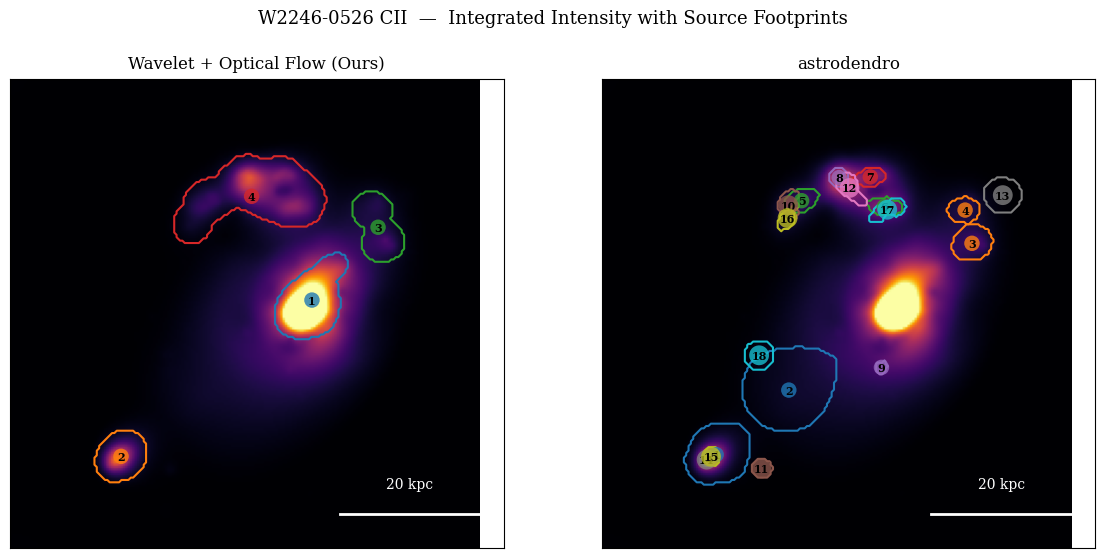

Saved ../results/comparison_w2246_314/comparison_mom0_footprints.png


In [9]:
plt.rcParams.update({
    'font.family':    'serif',
    'font.size':       11,
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

_det_idx = np.array(channel_list)
_mom0    = cube[_det_idx].sum(axis=0)
_vp0, _vp1 = np.nanpercentile(_mom0[_mom0 > 0], [2, 99])

_sb_kpc = 20.0
_sb_px  = _sb_kpc / pixscale_kpc

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
titles = ['Wavelet + Optical Flow (Ours)', 'astrodendro']

for ax, title in zip(axes, titles):
    ax.imshow(_mom0, cmap='inferno', origin='lower', vmin=_vp0, vmax=_vp1)
    ax.set_title(title, fontsize=12, fontfamily='serif', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    if BMAJ_PIX > 0:
        add_beam(ax, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(6, 6), color='white')
    ax.plot([W * 0.70, W * 0.70 + _sb_px], [H * 0.07, H * 0.07], color='white', lw=2)
    ax.text(W * 0.70 + _sb_px / 2, H * 0.12, f'{_sb_kpc:.0f} kpc',
            color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# Panel 1 — Ours
ax = axes[0]
for src in _good_chrono:
    fp = our_footprints[src['id']]
    if not fp.any(): continue
    color = src_colors[src['id']]
    ax.contour(fp.astype(float), [0.5], colors=[color], linewidths=1.5)
    rows, cols = np.where(fp)
    ax.text(cols.mean(), rows.mean(), str(_chrono_label[src['id']]),
            ha='center', va='center', fontsize=8, color='black', fontweight='bold',
            bbox=dict(boxstyle='circle,pad=0.2', fc=color, ec='none', alpha=0.8))

# Panel 2 — astrodendro
ax = axes[1]
for i, s in enumerate(dendro_sources):
    fp = s['footprint']
    if not fp.any(): continue
    color = _dendro_colors[i % len(_dendro_colors)]
    ax.contour(fp.astype(float), [0.5], colors=[color], linewidths=1.5)
    cy, cx = s['centroid_yx']
    ax.text(cx, cy, str(i + 1),
            ha='center', va='center', fontsize=8, color='black', fontweight='bold',
            bbox=dict(boxstyle='circle,pad=0.2', fc=color, ec='none', alpha=0.8))

fig.suptitle('W2246-0526 CII  —  Integrated Intensity with Source Footprints',
             fontsize=13, fontfamily='serif', y=1.01)
plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/comparison_mom0_footprints.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/comparison_mom0_footprints.pdf', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {_RESULTS_DIR}/comparison_mom0_footprints.png')

plt.rcParams.update(plt.rcParamsDefault)


## Comparison: Per-Source Spectra

Integrated spectrum over each source's spatial footprint (union mask for ours, projected leaf for astrodendro).


In [ ]:
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

n_our    = len(_good_chrono)
n_dendro = len(dendro_sources)
n_rows   = max(n_our, n_dendro, 1)

fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.8 * n_rows), squeeze=False)
fig.suptitle('Per-source Integrated Spectra', fontsize=13, fontfamily='serif')
axes[0, 0].set_title('Wavelet + Optical Flow (Ours)', fontsize=12, fontfamily='serif')
axes[0, 1].set_title('astrodendro', fontsize=12, fontfamily='serif')

def _plot_spectrum(ax, footprint, color, label, ch_range=None):
    if not footprint.any():
        ax.set_visible(False)
        return
    spec = cube[:, footprint].sum(axis=1)
    ax.plot(vel_array, spec, color=color, lw=1.5)
    if ch_range is not None:
        v0, v1 = vel_array[ch_range[0]], vel_array[ch_range[1]]
        ax.axvspan(min(v0, v1), max(v0, v1), alpha=0.12, color=color)
    ax.set_ylabel('Flux (Jy beam$^{-1}$)', fontsize=9)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=9)
    ax.minorticks_on()
    ax.text(0.03, 0.93, label, transform=ax.transAxes, fontsize=9, va='top',
            fontfamily='serif',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

# Column 0 — Ours
for row, src in enumerate(_good_chrono):
    fp = our_footprints[src['id']]
    det_chs = sorted(ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks'])
    ch_range = (det_chs[0], det_chs[-1]) if det_chs else None
    _plot_spectrum(axes[row, 0], fp, src_colors[src['id']],
                  f'Source {_chrono_label[src["id"]]}', ch_range)
for row in range(n_our, n_rows):
    axes[row, 0].set_visible(False)

# Column 1 — astrodendro
for row, s in enumerate(dendro_sources):
    color = _dendro_colors[row % len(_dendro_colors)]
    _plot_spectrum(axes[row, 1], s['footprint'], color,
                  f'Leaf {row+1}', s['ch_range'])
for row in range(n_dendro, n_rows):
    axes[row, 1].set_visible(False)

for j in range(2):
    axes[-1, j].set_xlabel('Velocity (km s$^{-1}$)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/comparison_spectra.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/comparison_spectra.pdf', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {_RESULTS_DIR}/comparison_spectra.png')

plt.rcParams.update(plt.rcParamsDefault)


## Summary Table

In [ ]:
def _iou_footprints(fp_a, fp_b):
    inter = (fp_a & fp_b).sum()
    union = (fp_a | fp_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0

print('=' * 72)
print(f'{"Method":<22} {"N sources":>10} {"N voxels":>10} {"Vel range (km/s)":>20}')
print('-' * 72)

for i, src in enumerate(_good_chrono):
    fp = our_footprints[src['id']]
    det_chs = sorted(ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks'])
    v0 = vel_array[det_chs[0]] if det_chs else np.nan
    v1 = vel_array[det_chs[-1]] if det_chs else np.nan
    nvox = int(sum(m.sum() for t in tracks if t['id'] in src['track_ids']
                   for m in t['masks'].values()))
    tag = f'Ours  src {_chrono_label[src["id"]]}'
    print(f'{tag:<22} {"":>10} {nvox:>10d} {f"[{v0:.0f}, {v1:.0f}]":>20}')

print(f'{"Ours  TOTAL":<22} {len(sources):>10d}')
print('-' * 72)

for i, s in enumerate(sofia_sources):
    v0, v1 = vel_array[s['ch_range'][0]], vel_array[s['ch_range'][1]]
    print(f'{f"SoFiA S+C  src {i+1}":<22} {"":>10} {s["n_voxels"]:>10d} '
          f'{f"[{v0:.0f}, {v1:.0f}]":>20}')
print(f'{"SoFiA S+C  TOTAL":<22} {len(sofia_sources):>10d}')
print('-' * 72)

for i, s in enumerate(dendro_sources[:8]):
    v0, v1 = vel_array[s['ch_range'][0]], vel_array[s['ch_range'][1]]
    print(f'{f"astrodendro  leaf {i+1}":<22} {"":>10} {s["n_voxels"]:>10d} '
          f'{f"[{v0:.0f}, {v1:.0f}]":>20}')
print(f'{"astrodendro  TOTAL":<22} {len(dendro_sources):>10d}')
print('=' * 72)

# Cross-method IoU for top sources
if len(_good_chrono) > 0 and len(sofia_sources) > 0:
    print('\nSpatial IoU: Ours vs SoFiA (best match per our source)')
    for src in _good_chrono:
        fp_ours = our_footprints[src['id']]
        best_iou = max((_iou_footprints(fp_ours, s['footprint']) for s in sofia_sources),
                       default=0.0)
        print(f'  Our source {_chrono_label[src["id"]]:>2d}  →  best SoFiA IoU = {best_iou:.3f}')

if len(_good_chrono) > 0 and len(dendro_sources) > 0:
    print('\nSpatial IoU: Ours vs astrodendro (best match per our source)')
    for src in _good_chrono:
        fp_ours = our_footprints[src['id']]
        best_iou = max((_iou_footprints(fp_ours, s['footprint']) for s in dendro_sources),
                       default=0.0)
        print(f'  Our source {_chrono_label[src["id"]]:>2d}  →  best dendro IoU = {best_iou:.3f}')